In [528]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [529]:
SCALE_HEIGHT = 8000
R = 1.66
GRAV = 9.8
CP = 1005 # J/kg/K
SIGMA = 5.670374419e-8  # W m-2 K-4

In [530]:
def pressure(p0,z):
    return p0*np.exp(-z/SCALE_HEIGHT)

def density(p0,z):
    return p0*np.exp(-z/SCALE_HEIGHT)

def optical_depth(t0,z):
    return t0*np.exp(-z/SCALE_HEIGHT)

def transmittance(t):
    np.exp(-t*R)

def height(p,p0):
    return -SCALE_HEIGHT*np.log(p/p0)

In [531]:
def black_body_irradiance(temp):
    return SIGMA * temp**4

def transmitted_sfc_flux(temp,t0,p0,p):
    bs = black_body_irradiance(temp)
    return bs*np.exp(-t0*R*(p0-p)/p0)

def flux_atm_up(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return ba*np.arange(len(p),0,-1)
    ba = black_body_irradiance(temp)
    return ba*(1 - np.exp(-t0*R*(p0-p)/p0))

def flux_atm_down(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return -ba*np.arange(0,len(p))
    ba = black_body_irradiance(temp)
    return ba*(np.exp(-t0*R*p/p0)-1)

def net_lw_rad_flux(temp_sfc,temp_atm,t0,p0,p):
    sfc_up = transmitted_sfc_flux(temp_sfc,t0,p0,p)
    atm_up = flux_atm_up(temp_atm,t0,p0,p)
    atm_down = flux_atm_down(temp_atm,t0,p0,p)
    return sfc_up + atm_up + atm_down

def flux_convergence(temp_sfc,temp_atm,t0,p0,p):
    b_sfc = black_body_irradiance(temp_sfc)
    b_atm = black_body_irradiance(temp_atm)
    # return b_sfc*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) - b_atm*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) + b_atm*t0*R/p0*np.exp(-t0*R*p/p0)
    ### NOT RIGHT ### just taking gradient of prior function instead
    return -(t0*R/p0*(b_sfc*np.exp(-t0*R/p0*(p0-p)) - b_atm*(np.exp(-t0*R/p0*(p0-p)) - np.exp(-t0*R*p/p0))))

def flux_atm_up_noniso(temp_profile, t0, p0, p):
    """Upward atmospheric flux at each level p for non-isothermal atmosphere."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_up = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers below pi (p' > pi)
        p_below = p[i:]          # pressure levels below level i (higher pressure)
        T_below = temp_profile[i:]
        B_below = black_body_irradiance(T_below)
        transmittance = np.exp(-kernel_factor * (p_below - pi))
        F_up[i] = np.trapezoid(B_below * kernel_factor * transmittance, p_below)
    return F_up

def flux_atm_down_noniso(temp_profile, t0, p0, p):
    """Downward atmospheric flux at each level p (negative = downward)."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_down = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers above pi (p' < pi)
        p_above = p[:i+1]        # pressure levels above level i (lower pressure)
        T_above = temp_profile[:i+1]
        B_above = black_body_irradiance(T_above)
        transmittance = np.exp(-kernel_factor * (pi - p_above))
        F_down[i] = -np.trapezoid(B_above * kernel_factor * transmittance, p_above)
    return F_down

def net_lw_rad_flux_noniso(temp_sfc, temp_profile, t0, p0, p):
    sfc_up  = transmitted_sfc_flux(temp_sfc, t0, p0, p)
    atm_up  = flux_atm_up_noniso(temp_profile, t0, p0, p)
    atm_down = flux_atm_down_noniso(temp_profile, t0, p0, p)
    return sfc_up + atm_up + atm_down


In [532]:
# def temp_atm(s, z):
#     return (s - GRAV*z)/CP

# # def ds_dt(dF_dt):
# #     return -GRAV * dF_dt

In [533]:
tau0 = 1.42
Fsw = -280

Tsfc = 303 # or 308.2?
S0_4 = -400
alpha_p = 0.3
Te = 265.1
emiss = 0.905
tstar = 1 - emiss
Tatm = 259.2

rho = 1000 # kg/m3
h = 1 # m
p0 = 100000 # pa
cp_water = 4184 # J⋅kg−1⋅K−1

In [534]:
# Use coarser grid to keep loop fast (p is 100k points — very slow)
p_coarse = np.linspace(p0 / 100, p0, 100)      # 500-level grid is much faster
dp = np.diff(p_coarse).mean()
z = height(p = p_coarse,p0 = p0)

p_mid = p_coarse - dp/2
z_mid = height(p = p_mid,p0 = p0)

In [535]:
dt = 60*60
n_iter = 10000
tol = 0.1 

In [536]:
gamma_d = 0.00977

rho_2m = 1.2
Csh = 10**-3
v0 = 5

In [537]:
sfc_temp = Tsfc
atm_profile = np.ones(len(p_coarse)) * Tatm
dse_profile = CP * atm_profile + GRAV*height(p = p_coarse, p0 = p0)

for i in range(n_iter):

    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)
    dTdt = -GRAV / CP * dFdp               # K/s
    delta_T = dTdt * dt
    atm_profile = atm_profile + delta_T

    dsdt = -GRAV * dFdp
    delta_s = dsdt * dt
    dse_profile = dse_profile + delta_s

    # surface temp change
    dTsdt = -(Fsw + F[-1])/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1]

    # if np.max(np.abs(delta_T)) < tol:
    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break


Converged at iteration 5944


In [538]:

# Ta_rad_z = (dse_profile - z*GRAV)/CP

Ta_rad_z = atm_profile
s_rad_z = dse_profile
Ts_rad = sfc_temp

In [539]:
Ts_rad

np.float64(321.60591075607294)

Text(0.5, 1.0, 'Radiative Equilibrium Atmospheric Temperature')

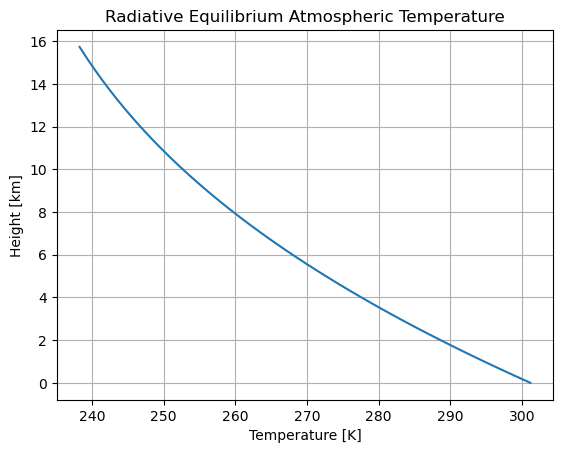

In [540]:
plt.grid()
plt.plot(Ta_rad_z[z<16000],z[z < 16000]/1000)
# plt.plot(atm_profile[z<16000],z[z < 16000]/1000)
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Atmospheric Temperature')

Text(0.5, 1.0, 'Radiative Equilibrium Atmospheric Dry Static Energy')

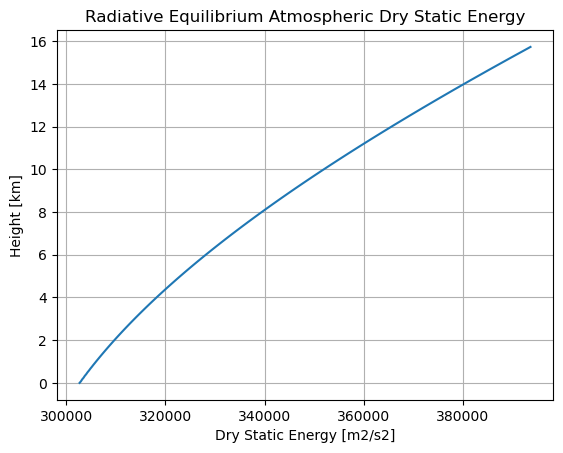

In [541]:
plt.grid()
plt.plot(dse_profile[z<16000],z[z < 16000]/1000)
plt.xlabel('Dry Static Energy [m2/s2]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Atmospheric Dry Static Energy')

In [542]:
dp/p0

np.float64(0.01)

In [543]:
T2m_rad = Ta_rad_z[-1] + (z_mid[-1] - 2)*gamma_d
T2m_rad

np.float64(301.5350077811096)

In [544]:
Ts_rad - T2m_rad

np.float64(20.07090297496336)

In [545]:
# sensible heat flux
Fsh = CP * rho_2m * Csh * v0 * (Ts_rad - T2m_rad)
Fsh

np.float64(121.02754493902904)

In [546]:
dTa1dt = (GRAV / CP)* (Fsh/dp)
dTa1dt * (60*60*24)

np.float64(101.96660980176584)

In [547]:
dp

np.float64(1000.0)

In [548]:
###### ADD IN SENSIBLE HEAT FLUX #########

z = height(p = p_coarse,p0 = p0)

sfc_temp = Tsfc
atm_profile = np.ones(len(p_coarse)) * Tatm
dse_profile = CP * atm_profile + GRAV*height(p = p_coarse, p0 = p0)

for i in range(n_iter):

    # net rad flux (LW)
    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    # radiative divergence
    dFdp = -np.gradient(F, p_coarse)
    # sensible heat 
    T2m = atm_profile[-1] + (z_mid[-1] - 2)*gamma_d
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)

    # dry static energy
    dsdt = -GRAV * dFdp
    delta_s = dsdt * dt
    dse_profile = dse_profile + delta_s

    dse_profile[-1] += (Fsh * GRAV / dp) * dt

    # convective adjustment: starting from the bottom, mix layers upward
    # while the running average exceeds the next layer above (unstable)
    n_mix = 1
    sbar = dse_profile[-1]
    while n_mix < len(dse_profile) and sbar > dse_profile[-1 - n_mix]:
        n_mix += 1
        sbar = dse_profile[-n_mix:].mean()
    dse_profile[-n_mix:] = sbar

    atm_profile = (dse_profile - z*GRAV)/CP

    # surface temp change
    dTsdt = -(Fsw + F[-1] + Fsh)/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break


In [549]:
sfc_temp

np.float64(317.7317060896561)

In [550]:
Ta_rad_dry_z = atm_profile
s_rad_dry_z = dse_profile
T2m_rad_dry = T2m
Ts_rad_dry = sfc_temp

(0.0, 16.0)

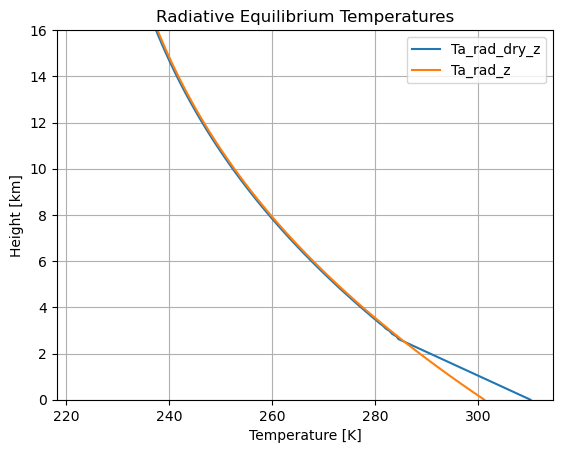

In [551]:
plt.plot(Ta_rad_dry_z,z/1000,label='Ta_rad_dry_z')
plt.plot(Ta_rad_z,z/1000,label='Ta_rad_z')
plt.grid()
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Temperatures')
plt.grid(True)
plt.legend()
plt.ylim(0,16)

(300.0, 400.0)

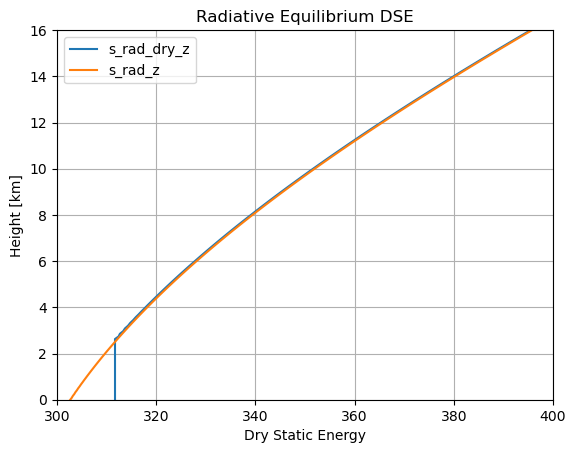

In [552]:
plt.plot(s_rad_dry_z/1000,z/1000,label='s_rad_dry_z')
plt.plot(s_rad_z/1000,z/1000,label='s_rad_z')
plt.grid()
plt.xlabel('Dry Static Energy')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium DSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(300,400)

In [553]:
T2m_rad_dry

np.float64(310.5115328997033)

In [554]:
Ts_rad_dry - T2m_rad_dry

np.float64(7.220173189952789)

In [555]:
Fsh

np.float64(43.537642934865964)

## Q4

In [616]:
LV = 2.25*10**6 #J/kg
RV = 461 #J kg−1K−1

In [617]:
def saturation_vapor_pressure(Ta):
    eref = 611
    Tref = 273
    return eref * np.exp((LV/RV)*((1/Tref) - (1/Ta)))

def saturation_mixing_ratio(Ta,p):
    es = saturation_vapor_pressure(Ta)
    return 0.622*es/(p-es)

def mixing_ratio(Ta,p,rel_hum):
    return rel_hum * saturation_mixing_ratio(Ta,p)



In [558]:
Ts_rad_dry

np.float64(317.7317060896561)

In [559]:
T2m_rad_dry

np.float64(310.5115328997033)

In [560]:
rel_hum_2m = 0.8
Clh = 10**-3
p2m = p0*np.exp(-2/SCALE_HEIGHT)

q_sfc = mixing_ratio(Ta = Ts_rad_dry, p = p0, rel_hum = 1)
q_2m = mixing_ratio(Ta = T2m_rad_dry, p = p2m, rel_hum = rel_hum_2m)
Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

In [561]:
Flh

np.float64(311.9642762810823)

In [562]:
((GRAV / CP) * (Flh / dp))*60*60*24

np.float64(262.8322308584259)

In [563]:
q_sat_atm = saturation_mixing_ratio(Ta_rad_dry_z, p_coarse)
h_sat_rad_dry_z = CP * Ta_rad_dry_z + GRAV * z + LV * q_sat_atm

Text(0.5, 1.0, 'Saturated MSE for Dry Radiative Convective Equilibrium')

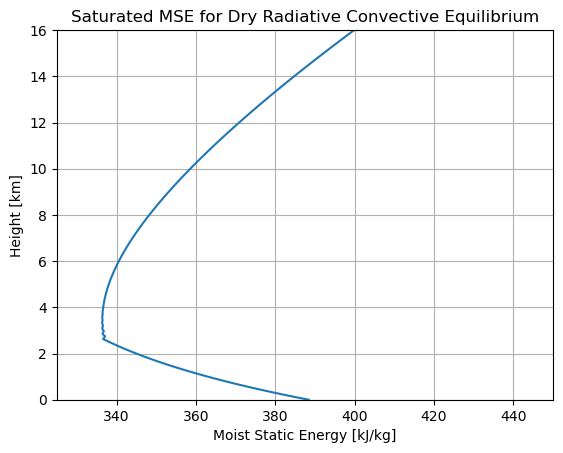

In [564]:
plt.plot(h_sat_rad_dry_z/1000,z/1000)
plt.ylim(0,16)
plt.xlim(325,450)
plt.grid()
plt.xlabel('Moist Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title("Saturated MSE for Dry Radiative Convective Equilibrium")

# Q5

In [565]:
###### ADD IN LATENT HEAT FLUX + MOIST CONVECTIVE ADJUSTMENT #########

def q_sat_capped(T, p):
    """Saturation mixing ratio with physical caps per Q5 constraints."""
    es = saturation_vapor_pressure(T)
    es = np.minimum(es, 0.99 * p)                      # e_sat cannot exceed p
    q  = 0.622 * es / (p - es)
    q  = np.minimum(q, 1.0)                            # cap at 1 kg/kg
    q  = np.where(p < 10000, np.minimum(q, 0.0015), q) # stratospheric cap
    return q

def h_mse(T, p, z):
    """Saturated moist static energy: h = cp*T + g*z + Lv*q_sat"""
    return CP * T + GRAV * z + LV * q_sat_capped(T, p)

def T_from_h(h_target, p, z):
    """Invert h = cp*T + g*z + Lv*q_sat(T,p) via vectorized bisection (60 iterations)."""
    T_lo = np.full_like(h_target, 150.0)
    T_hi = np.full_like(h_target, 500.0)
    for _ in range(60):
        T_mid = 0.5 * (T_lo + T_hi)
        h_mid = h_mse(T_mid, p, z)
        below = h_mid < h_target
        T_lo[ below] = T_mid[ below]
        T_hi[~below] = T_mid[~below]
    return 0.5 * (T_lo + T_hi)

z = height(p=p_coarse, p0=p0)

# Initialize from Q3 radiative-dry-convective equilibrium
sfc_temp    = Ts_rad_dry
atm_profile = Ta_rad_dry_z.copy()
mse_profile = h_mse(atm_profile, p_coarse, z)

for i in range(n_iter):

    # net LW flux
    F    = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)

    # 2m temperature and mixing ratios
    T2m   = atm_profile[-1] + (z_mid[-1] - 2) * gamma_d
    q_sfc = q_sat_capped(sfc_temp, p0)
    q_2m  = rel_hum_2m * q_sat_capped(T2m, p2m)

    # sensible and latent heat fluxes
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)
    Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

    # update moist static energy from radiative divergence
    mse_profile = mse_profile + (-GRAV * dFdp) * dt

    # add sensible + latent heat flux to lowest atmospheric layer
    mse_profile[-1] += (Fsh + Flh) * GRAV / dp * dt

    # moist convective adjustment: mix upward while column is unstable
    n_mix = 1
    hbar  = mse_profile[-1]
    while n_mix < len(mse_profile) and hbar > mse_profile[-1 - n_mix]:
        n_mix += 1
        hbar = mse_profile[-n_mix:].mean()
    mse_profile[-n_mix:] = hbar

    # recover temperature from moist static energy (numerical inversion)
    atm_profile = T_from_h(mse_profile, p_coarse, z)

    # re-derive mse from recovered T for consistency
    mse_profile = h_mse(atm_profile, p_coarse, z)

    # surface temperature update
    dTsdt    = -(Fsw + F[-1] + Fsh + Flh) / (cp_water * rho * h)
    sfc_temp = sfc_temp + dTsdt * dt

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh + Flh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break

# save results
Ta_rad_conv_z    = atm_profile
s_rad_conv_z     = CP * atm_profile + GRAV * z
h_sat_rad_conv_z = mse_profile
Ts_rad_conv      = sfc_temp
T2m_rad_conv     = T2m
n_mix_conv       = n_mix


In [566]:
Ts_rad_conv

np.float64(305.81244282988035)

In [567]:
T2m_rad_conv

np.float64(303.04549124599686)

In [568]:
Ts_rad_conv - T2m_rad_conv

np.float64(2.766951583883497)

(0.0, 16.0)

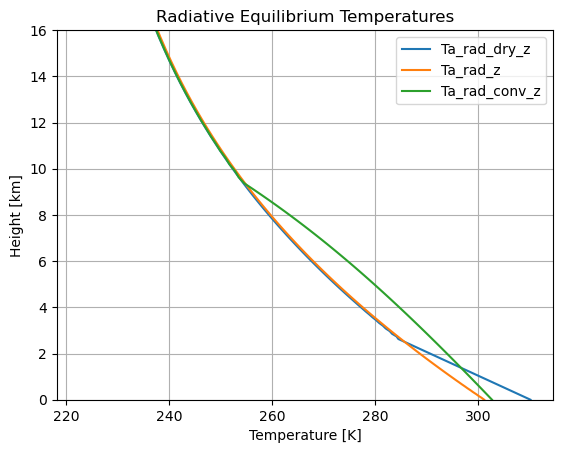

In [569]:
plt.plot(Ta_rad_dry_z,z/1000,label='Ta_rad_dry_z')
plt.plot(Ta_rad_z,z/1000,label='Ta_rad_z')
plt.plot(Ta_rad_conv_z,z/1000,label='Ta_rad_conv_z')
plt.grid()
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium Temperatures')
plt.grid(True)
plt.legend()
plt.ylim(0,16)

(300.0, 400.0)

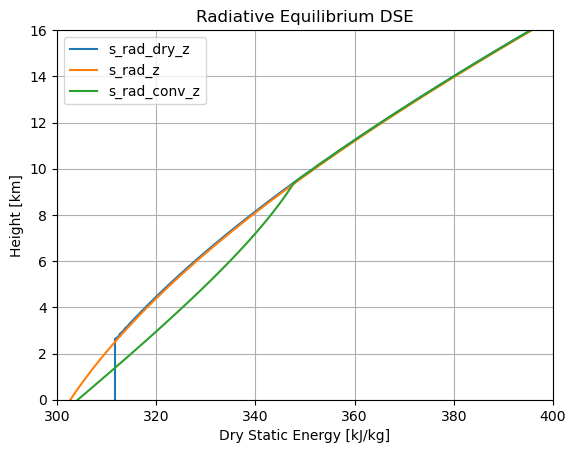

In [570]:
plt.plot(s_rad_dry_z/1000,z/1000,label='s_rad_dry_z')
plt.plot(s_rad_z/1000,z/1000,label='s_rad_z')
plt.plot(s_rad_conv_z/1000,z/1000,label='s_rad_conv_z')
plt.grid()
plt.xlabel('Dry Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium DSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(300,400)

(325.0, 400.0)

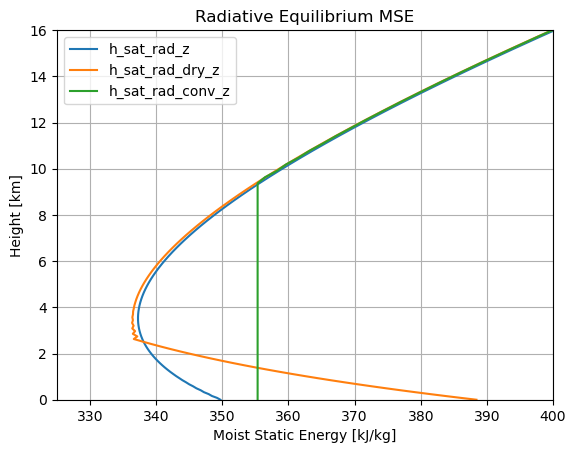

In [571]:

q_sat_rad_z = saturation_mixing_ratio(Ta_rad_z, p_coarse)
h_sat_rad_z = CP * Ta_rad_z + GRAV * z + LV * q_sat_rad_z

plt.plot(h_sat_rad_z/1000,z/1000,label='h_sat_rad_z')
plt.plot(h_sat_rad_dry_z/1000,z/1000,label='h_sat_rad_dry_z')
plt.plot(h_sat_rad_conv_z/1000,z/1000,label='h_sat_rad_conv_z')
plt.grid()
plt.xlabel('Moist Static Energy [kJ/kg]')
plt.ylabel('Height [km]')
plt.title('Radiative Equilibrium MSE')
plt.grid(True)
plt.legend()
plt.ylim(0,16)
plt.xlim(325,400)

In [572]:
# z[np.gradient(h_sat_rad_dry_z) > 0]
Ta_rad_dry_z[np.gradient(h_sat_rad_dry_z) > 0]

array([280.78042423, 281.51230015, 282.05034517, 282.83472094,
       283.29287376, 284.14777285, 284.51270695, 285.58872333,
       286.65009957, 287.69722871, 288.73048819, 289.75024063,
       290.7568346 , 291.75060536, 292.73187554, 293.70095571,
       294.65814502, 295.60373175, 296.53799382, 297.46119927,
       298.37360675, 299.27546593, 300.16701792, 301.04849567,
       301.92012429, 302.78212146, 303.63469771, 304.47805674,
       305.31239571, 306.13790553, 306.95477111, 307.76317161,
       308.56328068, 309.35526667, 310.13929287])

In [573]:
# z[np.abs(np.gradient(h_sat_rad_conv_z)) < 0.01]
Ta_rad_conv_z[np.abs(np.gradient(h_sat_rad_conv_z)) < 0.01]

array([256.31929246, 257.93884418, 259.47766076, 260.94252699,
       262.33953243, 263.67414351, 264.95127046, 266.17532844,
       267.35029275, 268.47974815, 269.56693269, 270.61477664,
       271.62593669, 272.60282623, 273.54764188, 274.4623869 ,
       275.34889184, 276.20883258, 277.04374638, 277.85504598,
       278.64403201, 279.41190408, 280.15977052, 280.88865704,
       281.59951448, 282.29322566, 282.9706115 , 283.63243654,
       284.27941379, 284.9122092 , 285.53144555, 286.13770606,
       286.73153758, 287.31345349, 287.88393633, 288.44344017,
       288.99239278, 289.53119756, 290.06023539, 290.57986618,
       291.0904304 , 291.59225044, 292.08563184, 292.57086444,
       293.04822342, 293.51797025, 293.98035362, 294.4356102 ,
       294.88396543, 295.32563422, 295.76082154, 296.18972309,
       296.6125258 , 297.02940836, 297.44054168, 297.84608936,
       298.24620808, 298.64104799, 299.03075304, 299.41546137,
       299.79530558, 300.17041302, 300.54090607, 300.90

# Q6

In [574]:
Fsw + F[-1]

np.float64(-130.53614784232838)

In [575]:
Fsh

np.float64(16.684719487896757)

In [576]:
Flh

np.float64(113.85170533706318)

In [577]:
(GRAV/CP)*Flh/dp * 60*60*24

np.float64(95.92091138606779)

In [622]:
(GRAV * 113)/(CP * p0) * 60 * 60 * 24

0.9520334328358209

(0.0, 16.0)

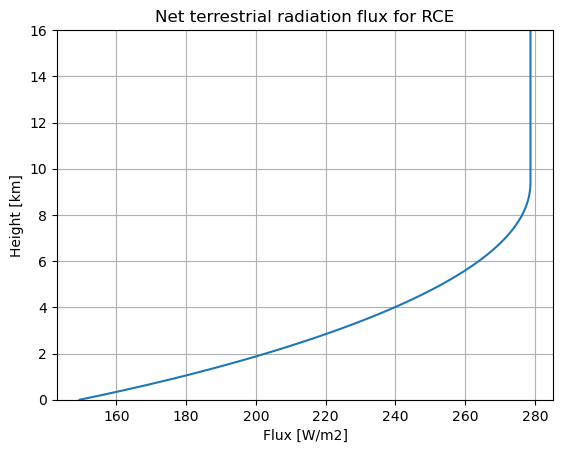

In [578]:

plt.plot(F,z/1000)
plt.grid()
plt.xlabel('Flux [W/m2]')
plt.ylabel('Height [km]')
plt.title('Net terrestrial radiation flux for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

(0.0, 16.0)

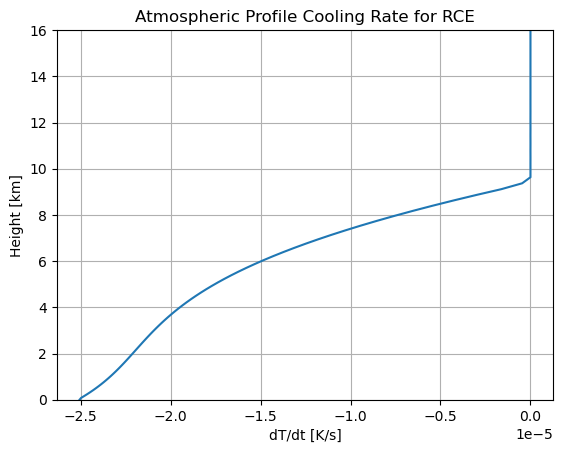

In [579]:


# plt.plot(h_sat_rad_z/1000,z/1000,label='h_sat_rad_z')
# plt.plot(h_sat_rad_dry_z/1000,z/1000,label='h_sat_rad_dry_z')

plt.plot((GRAV/CP)*np.gradient(F,p_coarse),z/1000)
plt.grid()
plt.xlabel('dT/dt [K/s]')
plt.ylabel('Height [km]')
plt.title('Atmospheric Profile Cooling Rate for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

In [580]:
(GRAV/CP)*np.gradient(F,p_coarse)[z < 16000].mean() * 60*60*24

np.float64(-1.2641383949834417)

# Q7

(0.0, 16.0)

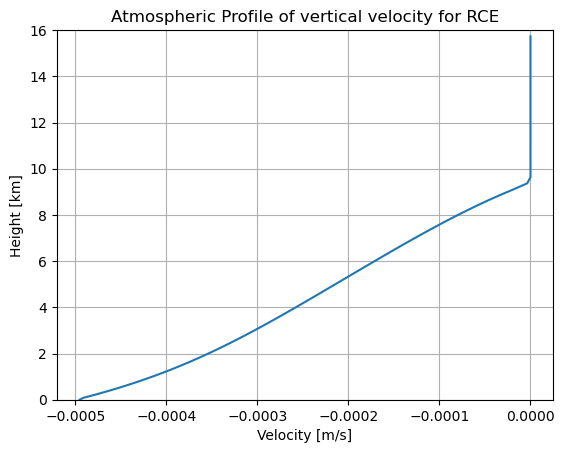

In [581]:
# rho_2m
w = ((-np.gradient(F,p_coarse)[z < 16000])/np.gradient(s_rad_conv_z,p_coarse)[z < 16000])/(rho_2m*GRAV)

plt.plot(w,z[z < 16000]/1000)
plt.grid()
plt.xlabel('Velocity [m/s]')
plt.ylabel('Height [km]')
plt.title('Atmospheric Profile of vertical velocity for RCE')
plt.grid(True)
# plt.legend()
plt.ylim(0,16)
# plt.xlim(300,400)

# Q8

In [582]:
(Flh / (rho * LV)) * 1000 * 60*60*24

np.float64(4.371905484943227)

In [583]:
q_sat_capped(Ta_rad_conv_z, p_coarse)[z<16000].mean() * rho_2m/rho * SCALE_HEIGHT * 1000

np.float64(113.76152004901436)

# Q9

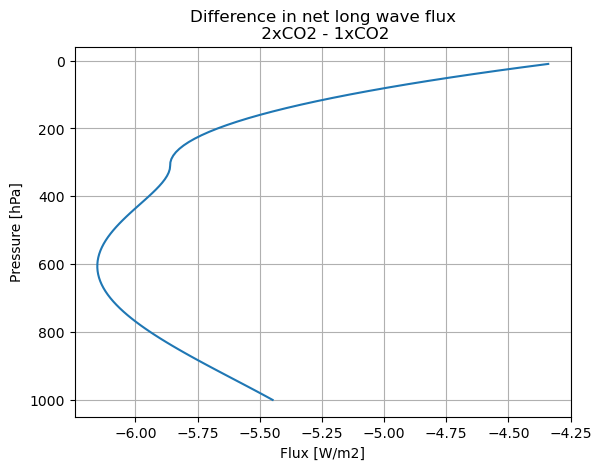

In [584]:
tau_2xco2 = 1.48
F_1xco2 = F
F_2xco2 = net_lw_rad_flux_noniso(Ts_rad_conv, Ta_rad_conv_z, tau_2xco2, p0, p_coarse)

plt.plot(F_2xco2 - F_1xco2,p_coarse/100)
# plt.plot(,p_coarse/100,label='2xCO2')
plt.ylabel('Pressure [hPa]')
plt.xlabel('Flux [W/m2]')
plt.title('Difference in net long wave flux\n 2xCO2 - 1xCO2')
plt.grid()
ax = plt.gca()
ax.yaxis.set_inverted(True)

In [585]:
(F_2xco2 - F_1xco2)[0]

np.float64(-4.340240552247963)

In [586]:
###### ADD IN LATENT HEAT FLUX + MOIST CONVECTIVE ADJUSTMENT #########

# Initialize from Q3 radiative-dry-convective equilibrium
sfc_temp    = Ts_rad_conv
atm_profile = Ta_rad_conv_z.copy()
mse_profile = h_sat_rad_conv_z

for i in range(n_iter):

    # net LW flux
    F    = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau_2xco2, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)

    # 2m temperature and mixing ratios
    T2m   = atm_profile[-1] + (z_mid[-1] - 2) * gamma_d
    q_sfc = q_sat_capped(sfc_temp, p0)
    q_2m  = rel_hum_2m * q_sat_capped(T2m, p2m)

    # sensible and latent heat fluxes
    Fsh = CP * rho_2m * Csh * v0 * (sfc_temp - T2m)
    Flh = LV * rho_2m * Clh * v0 * (q_sfc - q_2m)

    # update moist static energy from radiative divergence
    mse_profile = mse_profile + (-GRAV * dFdp) * dt

    # add sensible + latent heat flux to lowest atmospheric layer
    mse_profile[-1] += (Fsh + Flh) * GRAV / dp * dt

    # moist convective adjustment: mix upward while column is unstable
    n_mix = 1
    hbar  = mse_profile[-1]
    while n_mix < len(mse_profile) and hbar > mse_profile[-1 - n_mix]:
        n_mix += 1
        hbar = mse_profile[-n_mix:].mean()
    mse_profile[-n_mix:] = hbar

    # recover temperature from moist static energy (numerical inversion)
    atm_profile = T_from_h(mse_profile, p_coarse, z)

    # re-derive mse from recovered T for consistency
    mse_profile = h_mse(atm_profile, p_coarse, z)

    # surface temperature update
    dTsdt    = -(Fsw + F[-1] + Fsh + Flh) / (cp_water * rho * h)
    sfc_temp = sfc_temp + dTsdt * dt

    net_flux_toa = Fsw + F[0]
    net_flux_sfc = Fsw + F[-1] + Fsh + Flh

    if (np.abs(net_flux_toa) < tol) and (np.abs(net_flux_sfc) < tol):
        print(f"Converged at iteration {i}")
        break

# save results
Ta_rad_conv_z_2xco2    = atm_profile
s_rad_conv_z_2xco2     = CP * atm_profile + GRAV * z
h_sat_rad_conv_z_2xco2 = mse_profile
Ts_rad_conv_2xco2      = sfc_temp
T2m_rad_conv_2xco2     = T2m
n_mix_conv_2xco2       = n_mix


In [587]:
(Ts_rad_conv_2xco2 - Ts_rad_conv)/(F_2xco2 - F_1xco2)[0]

np.float64(-0.2129715896377139)

In [588]:
Ts_rad_conv_2xco2 - T2m_rad_conv_2xco2

np.float64(2.7329968318314855)

Text(0.5, 1.0, 'Change in RCE temperature\n2xCO2 - 1xCO2')

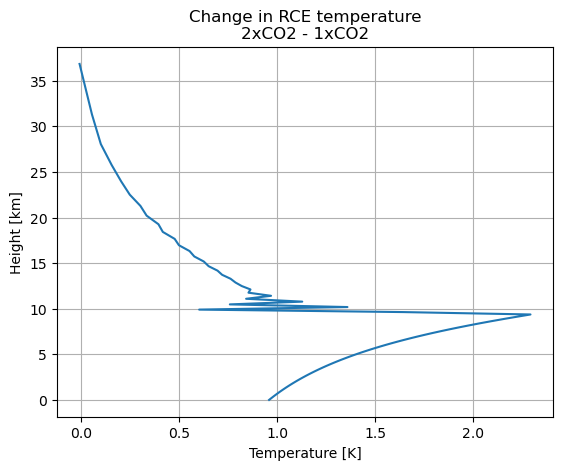

In [589]:
delta_T = Ta_rad_conv_z_2xco2 - Ta_rad_conv_z
plt.plot(delta_T[z < 40000],z[z<40000]/1000)
plt.xlabel('Temperature [K]')
plt.ylabel('Height [km]')
plt.grid()
plt.title('Change in RCE temperature\n2xCO2 - 1xCO2')

In [590]:
# z[np.abs(np.gradient(h_sat_rad_conv_z_2xco2)) < 0.01]
Ta_rad_conv_z_2xco2[np.abs(np.gradient(h_sat_rad_conv_z_2xco2)) < 0.01]

array([256.90425518, 258.540945  , 260.09375996, 261.57003614,
       262.9763147 , 264.31843198, 265.60160151, 266.83048749,
       268.00927003, 269.14170267, 270.23116296, 271.28069661,
       272.29305621, 273.2707349 , 274.21599588, 275.13089809,
       276.01731873, 276.87697289, 277.71143087, 278.52213324,
       279.31040421, 280.07746333, 280.82443583, 281.55236181,
       282.26220434, 282.95485664, 283.63114851, 284.29185205,
       284.93768674, 285.56932404, 286.18739143, 286.79247614,
       287.38512846, 287.96586466, 288.53516979, 289.0935    ,
       289.64128485, 290.17892925, 290.70681534, 291.22530409,
       291.73473686, 292.23543675, 292.7277099 , 293.21184662,
       293.68812247, 294.15679921, 294.61812575, 295.0723389 ,
       295.51966422, 295.96031664, 296.39450116, 296.82241345,
       297.24424037, 297.66016054, 298.07034477, 298.47495652,
       298.87415234, 299.26808223, 299.65688998, 300.04071356,
       300.41968538, 300.79393261, 301.16357746, 301.52

# Q10

In [591]:
net_flux_sfc = Fsw + F[-1] + Fsh + Flh

In [592]:
net_solar_terr_rad_2xco2 = Fsw + F[-1]
net_solar_terr_rad_2xco2

np.float64(-135.5451075709248)

In [593]:
(Fsh - 16.7)/16.7

np.float64(-0.013176016795880163)

In [594]:
(Flh - 113.8)/113.8

np.float64(0.046249095758275356)

In [595]:
(GRAV/CP)*(Flh/dp)*60*60*24

np.float64(100.3115899604168)

In [596]:
(100.3-95.9)/95.9

0.045881126173096885

In [597]:
(GRAV / CP)*np.gradient(F,p_coarse).mean()*60*60*24

np.float64(-1.1417923625102453)

In [598]:
(-1.14+1.26)/-1.26

-0.09523809523809532

# Q11

In [599]:
(Flh / (rho * LV))*1000*60*60*24

np.float64(4.572024848536003)

In [600]:
(4.57 - 4.37)/4.37

0.04576659038901606

In [601]:
q_sat_capped(Ta_rad_conv_z_2xco2, p_coarse)[z<16000].mean() * rho_2m/rho * SCALE_HEIGHT * 1000

np.float64(122.33167156107554)

In [602]:
(122.3 - 113.8)/113.8

0.07469244288224956